In [1]:
#This code is to test if the criteria \lambda_k > Q_k > \lambda_{k+1}
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from dynamics import *

In [2]:
#create invasion fitness matrix for invader-driven case
#n =  10 #number of strains in the dynamics
#invader = np.random.rand(n)

def make_fit(invader):
    k = len(invader)
    fit = np.zeros((k,k))
    for i in range (0, k):
        for j in range (0, k):
            if i != j:
                fit[i,j] = invader[i]
                
    return fit

In [3]:
#Compute Q using frequency at a time
def Q_compute(z, Lambda = None):
    n = len(z)
    
    if type(z) is list:
        z = np.array(z)
    z = np.array([10**(-30) if u<0  else u for u in list(z)])
    z = z/np.sum(z)
    
    if Lambda is None : 
        Lambda = np.array([[]])
        
    if type(Lambda) is list: 
        Lambda = np.array(Lambda)
        
    if np.shape(Lambda) != (len(z),len(z)):
        print('Attention mauvais lambda. Remplacement par une valeur par défaut')
        Lambda = np.ones((len(z),len(z)))
        
    Lambda = Lambda - np.diag(np.diag(Lambda))
    Q = np.dot(z.T,np.dot(Lambda,z))

    return Q

In [4]:
# Compute Q at equilibrium of invader driven system base on only fitness
def Qk(k, vector):
    Qk = 0
    for i in range (0, k):
        Qk = Qk + 1/vector[i]
    
    Qk = (k-1)/Qk
    
    return Qk

In [6]:
# Test the criterion in n random samples
nsamples = 10000
#n = 10 #number of strains in the dynamics
count = 0

for iter in range (0, nsamples):
    
    #create random number of strains in the dynamics
    n = random.randint(10, 20)
    
    #create random invader driven matrix
    invader = np.random.rand(n)
    fit = make_fit(invader)
    
    #create random intitial state
    u0 = np.random.rand(n)
    u0 = u0/sum(u0)
    
    #compute the dynamics and number of survival strains
    A, resultat, nc = simu(T = 400, fit=fit, z0 = u0)
    frequency = resultat.y[:,-1]
    Q = Q_compute(z = frequency, Lambda = fit) #Q at the the long time
    
    # Q*_k computed by invader fitness
    vector = np.sort(invader)[::-1]
    Q_k = Qk(nc, vector)
    
    # Test the criterion
    if nc < n:
        vector_nc = vector[nc]
    else:
        vector_nc = 0
        
    if vector[nc-1] > Q_k and vector_nc < Q_k:
        count += 1
        
# Proportion of correct cases that criterion holds
probs = (count/nsamples)*100
probs = np.round(probs,2)
print('Criterion is correct in {} % of cases'.format(probs))

Criterion is correct in 93.88 % of cases


In [13]:
#sample = 6
# APPENDIX
# Test if different intial values lead to the same long term behavior
n = 2
invader = -np.random.rand(n)
fit = make_fit(invader)
print(invader)

[-0.4555715  -0.99825044]


[0.31336128 0.68663872]
[0.31336128 0.68663872]
[0.40668064 0.59331936]
[ 1.00000000e+00 -1.35379161e-11]
[0.40668064 0.59331936]
[ 1.00000000e+00 -1.35379161e-11]
[0.31336128 0.68663872]
[0.31336128 0.68663872]
[0.40668064 0.59331936]
[ 1.00000000e+00 -1.35379161e-11]
[0.40668064 0.59331936]
[ 1.00000000e+00 -1.35379161e-11]


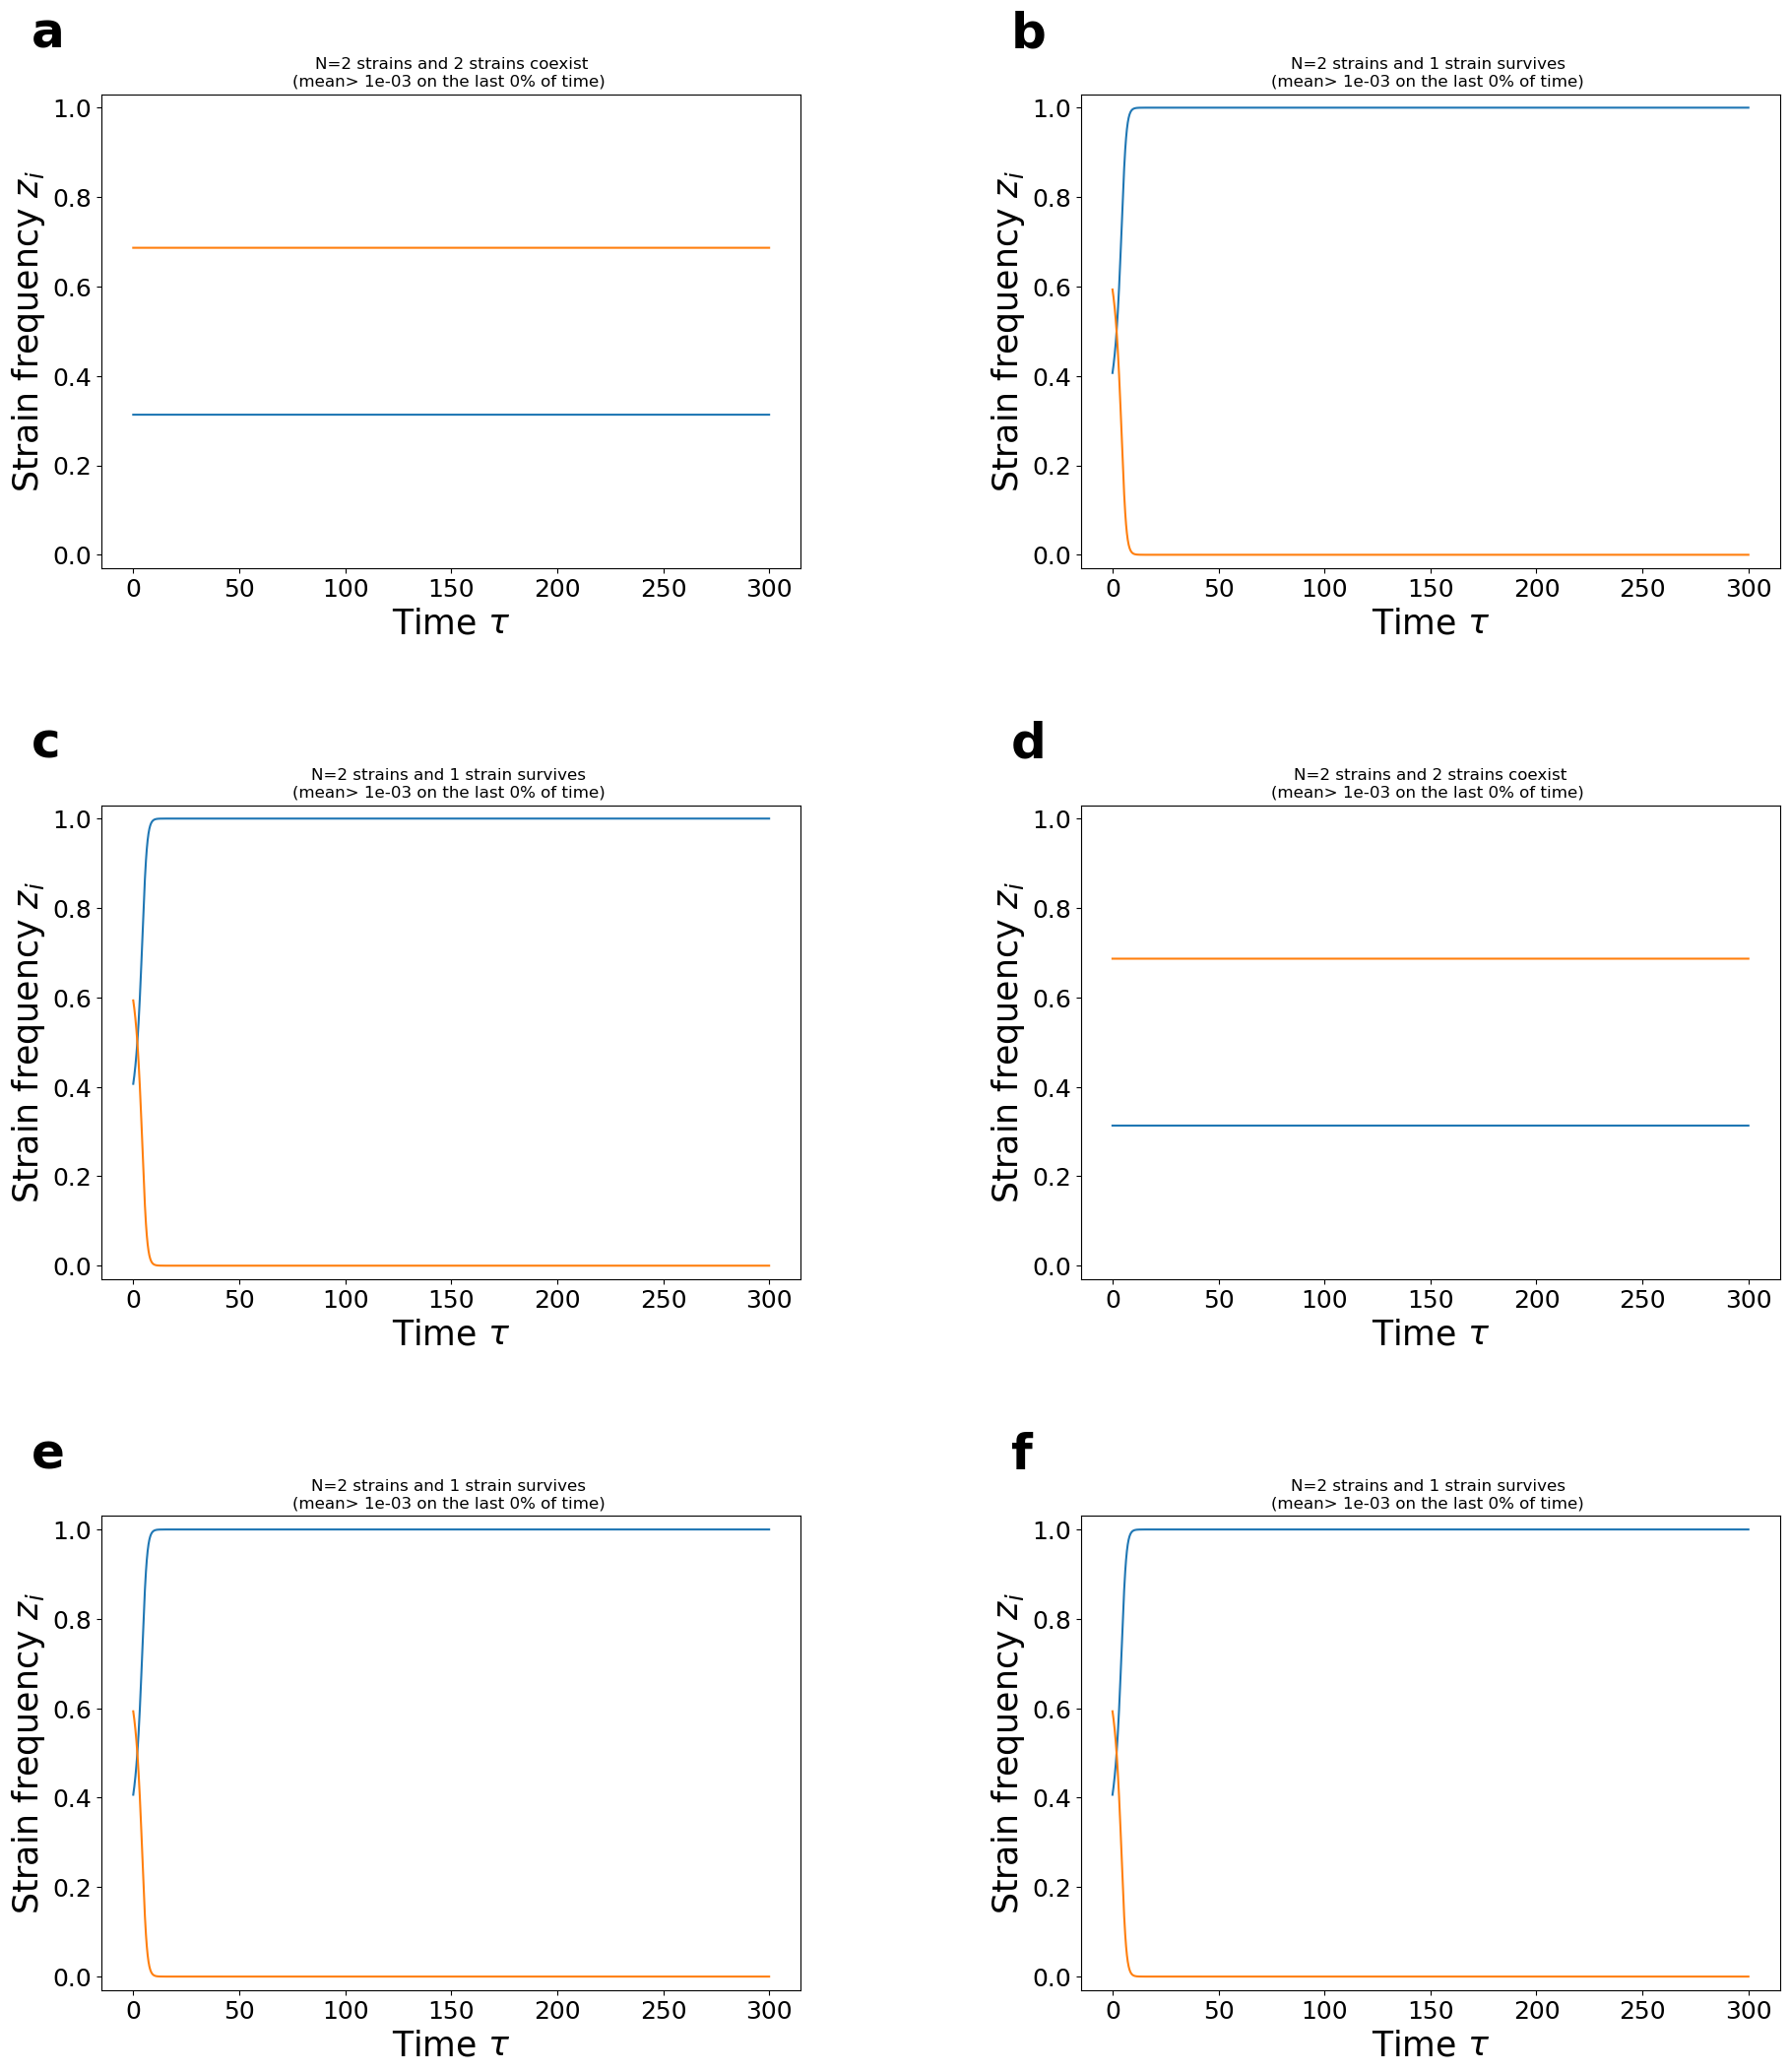

In [21]:
fig, ax = plt.subplots(3, 2, figsize = (22, 25))
plt.subplots_adjust(hspace = 0.5, wspace = 0.4)
label = np.array(['a', 'b', 'c', 'd', 'e', 'f'])
label = label.reshape(3, 2)

for i in range (0, 3):
    for j in range (0, 2):
        if i==j:
            u0 = invader/np.sum(invader)
        else:
        #u0 = np.random.rand(n)
        #u0 = np.ones(n)
        #u0 = u0/sum(u0)
            u0 = invader/np.sum(invader) + 0.5
            u0 = u0/np.sum(u0)
        
        result, ax[i,j] = plot_dynamics(T = 300, fit = fit, z0 = u0, ax = ax[i,j])
        
        ax[i,j].tick_params(axis='both', which='major', labelsize = 18)
        
        ax[i,j].text(-.1, 1.1, '{}'.format(label[i,j]), transform=ax[i,j].transAxes, size = 36, weight='bold')
        A, resultat, nc = simu(T = 200, fit=fit, z0 = u0)
        frequency = resultat.y[:,-1]
        ax[i,j].set_ylim(-0.03, 1.03)
        #Q = Q_compute(z = frequency, Lambda = fit)
        #print(Q)
        print(u0)
        print(frequency)

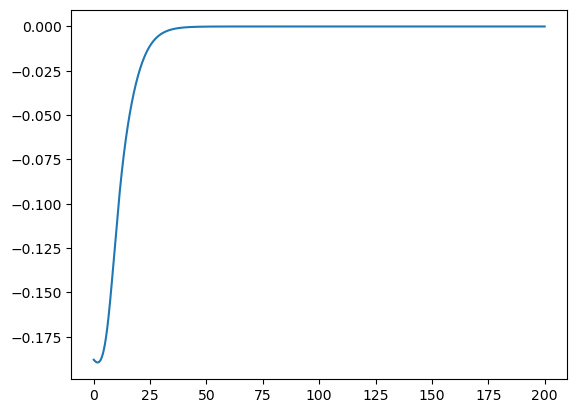

In [31]:
u0 = np.random.rand(n)
u0 = u0/sum(u0)
T = 200
details = T*10

A, resultat, nc = simu(T = T, fit=fit, z0 = u0)
y = resultat.sol(np.linspace(0, T, details))

Q = []
for i in range (0, details):
    Q.append(Q_compute(z = y[:,i], Lambda = fit))

fig, ax = plt.subplots()
ax.plot(np.linspace(0, T, details), Q)

In [ ]:
vector = np.sort(invader)[::-1]
print(vector)
print(Qk(nc,vector))